In [18]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


from sklearn.metrics import roc_curve, auc , confusion_matrix, accuracy_score
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import train_test_split


from keras.models import load_model
from keras.callbacks import EarlyStopping, ReduceLROnPlateau
from keras.optimizers import RMSprop


from dataset_preparation import awgn, LoadDataset, ChannelIndSpectrogram
from deep_learning_models import TripletNet, identity_loss

In [19]:
# SPECIFIC MODULES INSTALLED MANUALLY
#%pip install keras
#%pip install tensorflow
#%pip install gdrive
#%pip install matplotlib


#!unzip -q /workspaces/work/dataset_training_aug.zip
training_dataset_path = "/workspaces/work/Dataset/dataset_training_no_aug.h5"
#"/workspaces/work/Dataset/dataset_training_aug.h5"


In [20]:
file_path = training_dataset_path        
dev_range = np.arange(0,30, dtype = int), 
pkt_range = np.arange(0,500, dtype = int), 
#pkt_range = np.arange(0,1000, dtype = int),
snr_range = np.arange(20,80)

LoadDatasetObj = LoadDataset()
    
# Load preamble IQ samples and labels.
data, label = LoadDatasetObj.load_iq_samples(file_path, 
                                                 dev_range, 
                                                 pkt_range)

Dataset information: Dev 1 to Dev 30, 500 packets per device.


In [21]:
data[0].shape

(8192,)

In [22]:
def train_feature_extractor(
    file_path = 
    '/workspaces/work/Dataset/dataset_training_no_aug.h5'
    #'/workspaces/work/Dataset/dataset_training_aug.h5'
    
        # './dataset/Train/dataset_training_aug.h5'  
        , 
    dev_range = np.arange(0,30, dtype = int), 
    pkt_range = np.arange(0,500, dtype = int), 
    snr_range = np.arange(20,80)
                            ):

                            
    '''
    train_feature_extractor trains an RFF extractor using triplet loss.
    
    INPUT: 
        FILE_PATH is the path of training dataset.
        
        DEV_RANGE is the label range of LoRa devices to train the RFF extractor.
        
        PKT_RANGE is the range of packets from each LoRa device to train the RFF extractor.
        
        SNR_RANGE is the SNR range used in data augmentation. 
        
    RETURN:
        FEATURE_EXTRACTOR is the RFF extractor which can extract features from
        channel-independent spectrograms.
    '''
    
    LoadDatasetObj = LoadDataset()
    
    # Load preamble IQ samples and labels.
    data, label = LoadDatasetObj.load_iq_samples(file_path, 
                                                 dev_range, 
                                                 pkt_range)
        
    # Add additive Gaussian noise to the IQ samples.
    data = awgn(data, snr_range)
    
    ChannelIndSpectrogramObj = ChannelIndSpectrogram()
    
    # Convert time-domain IQ samples to channel-independent spectrograms.
    data = ChannelIndSpectrogramObj.channel_ind_spectrogram(data)
    
    return data, label
    

Dataset information: Dev 1 to Dev 30, 500 packets per device.


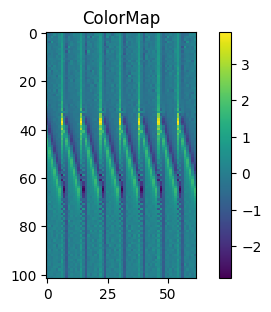

In [23]:
data, label = train_feature_extractor()

# # VISUALISE A SAMPLE
test_sample = data[3].reshape(102,62)
plt.figure(figsize=(6, 3.2))
plt.imshow(test_sample, cmap='viridis', interpolation='nearest')
plt.colorbar()
plt.title('ColorMap')
plt.show()

In [30]:
data[0].shape

(102, 62, 1)

In [17]:
#total_samples, height, width, _ = data.shape
#data_reshaped = data.reshape(total_samples, height, width)
#data_reshaped.shape

#data_real_values_train2, data_real_values_test2, label_train2, label_test2 = train_test_split(data_real_values, 
 #                                                                    label, 
  #                                                                  test_size=0.2, 
 #                                                                    shuffle= True)


#SOME PREPROCESSING



#data_real_values_train, data_real_values_test, label_train, label_test = train_test_split(data_real_values, label, test_size=0.2, random_state=30)



In [9]:
total_samples, height, width, _ = data.shape
data_reshaped = data.reshape(total_samples, height, width)
data_reshaped.shape

data_reshaped_train2, data_reshaped_test2, label_train2, label_test2 = train_test_split(data_reshaped, 
                                                                     label, 
                                                                    test_size=0.2, 
                                                                    shuffle= True)

#SOME PREPROCESSING



#data_real_values_train, data_real_values_test, label_train, label_test = train_test_split(data_real_values, label, test_size=0.2, random_state=30)



In [31]:
data_reshaped.shape

(15000, 102, 62)

In [34]:
import tensorflow as tf
import keras
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import  Conv1D, Conv2D, MaxPooling1D, MaxPooling2D, Flatten, Dense
import matplotlib.pyplot as plt
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout, GRU, SimpleRNN


cnn_model2 = Sequential()
cnn_model2.add(Conv2D(filters=32, kernel_size=(3,3), activation='relu', padding='same', input_shape=(height, width, 1)))
#cnn_model2.add(MaxPooling1D(pool_size=2, padding='same'))
#cnn_model2.add(Dropout(0.2))
cnn_model2.add(Conv2D(64, kernel_size=1, activation='relu'))
cnn_model2.add(Conv2D(64, kernel_size=1, activation='relu'))
cnn_model2.add(Flatten())
cnn_model2.add(Dense(64, activation='relu'))
cnn_model2.add(Dense(1, activation='sigmoid'))

#cnn_model2.summary()

/home/codespace/.python/current/lib/python3.10/site-packages/keras/src/layers/convolutional/base_conv.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [69]:
# Create a Sequential model
mlp_model = Sequential()

# Add layers to the model
mlp_model.add(Dense(128, activation='relu', input_shape=(height, width, 1)))  # Input layer with 10 input features and 128 neurons
mlp_model.add(Dense(64, activation='relu'))                # Hidden layer with 64 neurons and ReLU activation
mlp_model.add(Dense(32, activation='relu'))                # Another hidden layer with 32 neurons and ReLU activation
mlp_model.add(Dense(1, activation='sigmoid'))              # Output layer with 1 neuron and sigmoid activation for binary classification



# Print the model summary
#model.summary()

/home/codespace/.python/current/lib/python3.10/site-packages/keras/src/layers/core/dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [38]:
# Define the LSTM model
lstm_model = Sequential()
lstm_model.add(LSTM(128, activation='relu', input_shape=(height, width)))
lstm_model.add(Dense(128, activation='relu'))
lstm_model.add(Dropout(0.5))
lstm_model.add(Dense(1, activation='sigmoid'))


In [39]:
simpleRNN_model = Sequential()

# Add SimpleRNN layer to the model
simpleRNN_model.add(SimpleRNN(64, input_shape=(height, width)))  # SimpleRNN layer with 64 units and input shape (10, 1)

# Add Dense layer to the model
simpleRNN_model.add(Dense(1, activation='sigmoid'))  # Output layer with sigmoid activation for binary classification
#model.summary()

In [41]:
gru_model = Sequential()

# Add GRU layer to the model
gru_model.add(GRU(64, input_shape=(height, width)))  # GRU layer with 64 units and input shape (10, 1)

# Add Dense layer to the model
gru_model.add(Dense(1, activation='sigmoid'))  # Output layer with sigmoid activation for binary classification

In [68]:
#for cnn_lstm
from keras.models import Sequential
from keras.layers import Conv2D, MaxPooling2D, Flatten, LSTM, Dense, SimpleRNN, GRU

# Create a Sequential model for CNN
cnn_model = Sequential()
cnn_model.add(Conv2D(32, kernel_size=(3, 3), activation='relu', input_shape=(102, 62, 1)))
cnn_model.add(MaxPooling2D(pool_size=(2, 2)))
cnn_model.add(Conv2D(64, kernel_size=(3, 3), activation='relu'))
cnn_model.add(MaxPooling2D(pool_size=(2, 2)))
cnn_model.add(Flatten())
cnn_model.add(Dense(128, activation='relu'))
cnn_model.add(Dense(1, activation='sigmoid'))

# Create a Sequential model for LSTM
lstm_model = Sequential()
lstm_model.add(LSTM(128, input_shape=(102, 62)))
lstm_model.add(Dense(1, activation='sigmoid'))

models = [cnn_model, lstm_model, mlp_model]
for model in models:
    model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

train_history = model.fit(data_reshaped_train2, label_train2, 
                                   validation_data = (data_reshaped_test2, label_test2),
                                   epochs=1, batch_size=32)

375/375 ━━━━━━━━━━━━━━━━━━━━ 9s 22ms/step - accuracy: 0.0311 - loss: -180094800.0000 - val_accuracy: 0.0360 - val_loss: -505584416.0000


In [61]:
#for CNN_LSTM_MLP
from keras.models import Sequential
from keras.layers import Conv2D, MaxPooling2D, Flatten, LSTM, Dense, SimpleRNN, GRU

# Create a Sequential model for CNN
cnn_model = Sequential()
cnn_model.add(Conv2D(32, kernel_size=(3, 3), activation='relu', input_shape=(102, 62, 1)))
cnn_model.add(MaxPooling2D(pool_size=(2, 2)))
cnn_model.add(Conv2D(64, kernel_size=(3, 3), activation='relu'))
cnn_model.add(MaxPooling2D(pool_size=(2, 2)))
cnn_model.add(Flatten())
cnn_model.add(Dense(128, activation='relu'))
cnn_model.add(Dense(1, activation='sigmoid'))

# Create a Sequential model for LSTM
lstm_model = Sequential()
lstm_model.add(LSTM(128, input_shape=(102, 62)))
lstm_model.add(Dense(1, activation='sigmoid'))

# Create a Sequential model for MLP
mlp_model = Sequential()
mlp_model.add(Dense(256, activation='relu', input_shape=(102, 62)))
mlp_model.add(Flatten())
mlp_model.add(Dense(128, activation='relu'))
mlp_model.add(Dense(1, activation='sigmoid'))

 #Compile models
models = [cnn_model, lstm_model, mlp_model]
for model in models:
    model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

train_history = model.fit(data_reshaped_train2, label_train2, 
                                   validation_data = (data_reshaped_test2, label_test2),
                                   epochs=1, batch_size=32)

/home/codespace/.python/current/lib/python3.10/site-packages/keras/src/layers/convolutional/base_conv.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
/home/codespace/.python/current/lib/python3.10/site-packages/keras/src/layers/rnn/rnn.py:204: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)
/home/codespace/.python/current/lib/python3.10/site-packages/keras/src/layers/core/dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activit

375/375 ━━━━━━━━━━━━━━━━━━━━ 9s 22ms/step - accuracy: 0.0330 - loss: -6539288.5000 - val_accuracy: 0.0360 - val_loss: -118332544.0000


In [55]:
#for CNN_LSTM_MLP_SIMPLERNN
from keras.models import Sequential
from keras.layers import Conv2D, MaxPooling2D, Flatten, LSTM, Dense, SimpleRNN, GRU

# Create a Sequential model for CNN
cnn_model = Sequential()
cnn_model.add(Conv2D(32, kernel_size=(3, 3), activation='relu', input_shape=(102, 62, 1)))
cnn_model.add(MaxPooling2D(pool_size=(2, 2)))
cnn_model.add(Conv2D(64, kernel_size=(3, 3), activation='relu'))
cnn_model.add(MaxPooling2D(pool_size=(2, 2)))
cnn_model.add(Flatten())
cnn_model.add(Dense(128, activation='relu'))
cnn_model.add(Dense(1, activation='sigmoid'))

# Create a Sequential model for LSTM
lstm_model = Sequential()
lstm_model.add(LSTM(128, input_shape=(102, 62)))
lstm_model.add(Dense(1, activation='sigmoid'))

# Create a Sequential model for MLP
mlp_model = Sequential()
mlp_model.add(Dense(256, activation='relu', input_shape=(102, 62)))
mlp_model.add(Flatten())
mlp_model.add(Dense(128, activation='relu'))
mlp_model.add(Dense(1, activation='sigmoid'))

# Create a Sequential model for SimpleRNN
simplernn_model = Sequential()
simplernn_model.add(SimpleRNN(128, input_shape=(102, 62)))
simplernn_model.add(Dense(1, activation='sigmoid'))

models = [cnn_model, lstm_model, mlp_model, simplernn_model, gru_model]
for model in models:
    model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])
    
train_history = model.fit(data_reshaped_train2, label_train2, 
                                   validation_data = (data_reshaped_test2, label_test2),
                                   epochs=1, batch_size=32)

In [58]:
#for CNN_LSTM_MLP_SIMPLERNN_GRU
from keras.models import Sequential
from keras.layers import Conv2D, MaxPooling2D, Flatten, LSTM, Dense, SimpleRNN, GRU

# Create a Sequential model for CNN
cnn_model = Sequential()
cnn_model.add(Conv2D(32, kernel_size=(3, 3), activation='relu', input_shape=(102, 62, 1)))
cnn_model.add(MaxPooling2D(pool_size=(2, 2)))
cnn_model.add(Conv2D(64, kernel_size=(3, 3), activation='relu'))
cnn_model.add(MaxPooling2D(pool_size=(2, 2)))
cnn_model.add(Flatten())
cnn_model.add(Dense(128, activation='relu'))
cnn_model.add(Dense(1, activation='sigmoid'))

# Create a Sequential model for LSTM
lstm_model = Sequential()
lstm_model.add(LSTM(128, input_shape=(102, 62)))
lstm_model.add(Dense(1, activation='sigmoid'))

# Create a Sequential model for MLP
mlp_model = Sequential()
mlp_model.add(Dense(256, activation='relu', input_shape=(102, 62)))
mlp_model.add(Flatten())
mlp_model.add(Dense(128, activation='relu'))
mlp_model.add(Dense(1, activation='sigmoid'))

# Create a Sequential model for SimpleRNN
simplernn_model = Sequential()
simplernn_model.add(SimpleRNN(128, input_shape=(102, 62)))
simplernn_model.add(Dense(1, activation='sigmoid'))

# Create a Sequential model for GRU
gru_model = Sequential()
gru_model.add(GRU(128, input_shape=(102, 62)))
gru_model.add(Dense(1, activation='sigmoid'))

# Compile models
models = [cnn_model, lstm_model, mlp_model, simplernn_model, gru_model]
for model in models:
    model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

# Print model summaries
#for i, model in enumerate(models):
  #  print(f"Model {i+1} Summary:")
  #  print(model.summary())
  #  print("\n")

train_history = model.fit(data_reshaped_train2, label_train2, 
                                   validation_data = (data_reshaped_test2, label_test2),
                                   epochs=1, batch_size=32)

/home/codespace/.python/current/lib/python3.10/site-packages/keras/src/layers/convolutional/base_conv.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
/home/codespace/.python/current/lib/python3.10/site-packages/keras/src/layers/rnn/rnn.py:204: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)
/home/codespace/.python/current/lib/python3.10/site-packages/keras/src/layers/core/dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activit

375/375 ━━━━━━━━━━━━━━━━━━━━ 17s 42ms/step - accuracy: 0.0330 - loss: -305.2356 - val_accuracy: 0.0360 - val_loss: -851.5466


In [28]:
model_to_train = cnn_model2
#model_to_train = cnn_model
#model_to_train = lstm_model
#model_to_train = CuDNNlstm_model
#model_to_train = cnn_lstm_model
#model_to_train = mlp_model
#model_to_train = simpleRNN_model
#model_to_train = gru_model
#model_to_train=CNN_LSTM_model

#loss1 = 'sparse_categorical_crossentropy'
loss2 = 'binary_crossentropy'
#loss3 = keras.losses.BinaryFocalCrossentropy()


#optimizer = keras.optimizers.Adam(learning_rate=0.0001) #https://keras.io/api/optimizers/adam/
optimizer = keras.optimizers.RMSprop(learning_rate=0.001) # https://keras.io/api/optimizers/rmsprop/
#optimizer = keras.optimizers.SGD(learning_rate=0.001) #https://keras.io/api/optimizers/sgd/




model_to_train.compile(optimizer=optimizer, loss=loss2, metrics=['accuracy'])
train_history = model_to_train.fit(data_reshaped_train2, label_train2, 
                                   validation_data = (data_reshaped_test2, label_test2),
                                   epochs=1, batch_size=32)


#model_to_train.compile(optimizer=optimizer, loss=loss3, metrics=['accuracy'])

#train_history = model_to_train.fit(data, label, 
#                                   epochs=1, batch_size=32)

375/375 ━━━━━━━━━━━━━━━━━━━━ 86s 227ms/step - accuracy: 0.0371 - loss: -49976623104.0000 - val_accuracy: 0.0300 - val_loss: -297223323648.0000


In [ ]:
import numpy as np
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, LSTM, Dense, TimeDistributed, Flatten

# Define input shape for CNN
input_shape = (10, 64, 64, 3)  # 10 frames of 64x64 RGB images

# Create a Sequential model
model = Sequential()

# CNN layers
model.add(TimeDistributed(Conv2D(32, (3, 3), activation='relu'), input_shape=input_shape))
model.add(TimeDistributed(MaxPooling2D((2, 2))))
model.add(TimeDistributed(Conv2D(64, (3, 3), activation='relu')))
model.add(TimeDistributed(MaxPooling2D((2, 2))))
model.add(TimeDistributed(Flatten()))

# LSTM layer
model.add(LSTM(128, return_sequences=False))

# Output layer
model.add(Dense(1, activation='sigmoid'))

# Compile the model
model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

# Print the model summary
#model.summary()

In [85]:
model_to_train.save('2_first_model.h5')

In [86]:
# load and evaluate a saved model
from numpy import loadtxt
from tensorflow.keras.models import load_model
 
# load model
model = load_model('2_first_model.h5')
# summarize model.
model.summary()

# evaluate the model
score = model.evaluate(data_real_values_test, label_test, verbose=0)
print("%s: %.2f%%" % (model.metrics_names[1], score[1]*100))

Model: "sequential_10"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv1d_24 (Conv1D)              │ (None, 1, 32)          │       786,464 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_25 (Conv1D)              │ (None, 1, 64)          │         2,112 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_26 (Conv1D)              │ (None, 1, 64)          │         4,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_6 (Flatten)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_22 (Dense)                │ (None, 64)             │         4,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_23 (Dense)                │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 796,963 (3.04 MB)

 Trainable params: 796,961 (3.04 MB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 2 (12.00 B)

compile_metrics: 95.50%


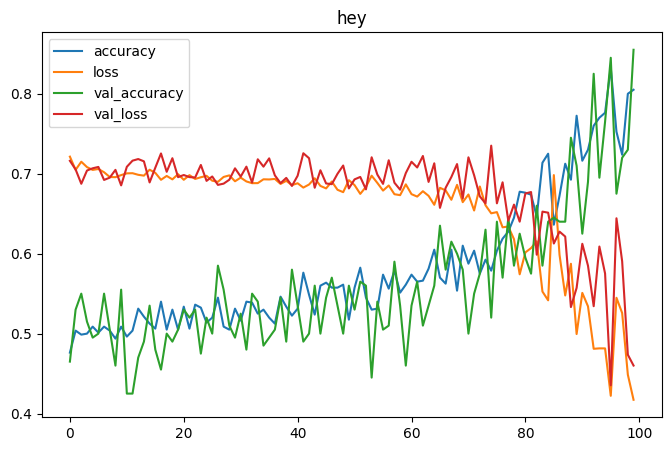

In [9]:
import pandas as pd
pd.DataFrame(train_history.history).plot(figsize=(8,5))
plt.title(f'hey')
# plt.savefig('./Plots/Base_model/7.')
plt.show()

In [9]:
print(np.unique(label))

[0 1]
